# Word2Vec: Converting Words to Vectors

This notebook demonstrates how to use pre-trained Word2Vec models to convert words into dense numerical vectors (embeddings). Word2Vec is a foundational technique in NLP that captures semantic meaning by learning representations where words with similar meanings have similar vectors.

## Installation

First, let's install the necessary libraries:

In [1]:
# Install required packages
import subprocess
import sys

packages = ['gensim', 'numpy', 'matplotlib', 'scikit-learn']
for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("All packages installed successfully!")

All packages installed successfully!


## Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.models import KeyedVectors
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Train a Simple Word2Vec Model for Classroom Demo

For this demonstration, we'll train a compact Word2Vec model on sample text. This is perfect for understanding the concepts and runs quickly on any computer.

In [ ]:
# Try to download a smaller pre-trained model, or train a compact one
print("Attempting to download a lightweight pre-trained model...\n")

try:
    import gensim.downloader as api
    
    # Try downloading a smaller model (GloVe - similar to Word2Vec)
    print("Downloading glove-wiki-gigaword-50 (50-dimensional vectors)...")
    model = api.load("glove-wiki-gigaword-50")
    
    print("✓ Model loaded successfully!")
    print(f"Vocabulary size: {len(model)}")
    print(f"Vector dimension: {model.vector_size}")
    
except Exception as e:
    print(f"Note: Could not download model ({e})")
    print("\nTraining a compact Word2Vec model instead...\n")
    
    from gensim.models import Word2Vec
    
    # Sample sentences for training
    training_sentences = [
        # Royal/Gender relationships
        ['the', 'king', 'is', 'a', 'powerful', 'man'],
        ['the', 'queen', 'is', 'a', 'powerful', 'woman'],
        ['the', 'prince', 'is', 'a', 'young', 'boy'],
        ['the', 'princess', 'is', 'a', 'young', 'girl'],
        
        # Geography
        ['paris', 'is', 'the', 'capital', 'of', 'france'],
        ['london', 'is', 'the', 'capital', 'of', 'england'],
        ['berlin', 'is', 'the', 'capital', 'of', 'germany'],
        ['madrid', 'is', 'the', 'capital', 'of', 'spain'],
        
        # Animals and descriptions
        ['the', 'cat', 'is', 'a', 'cute', 'animal'],
        ['the', 'dog', 'is', 'a', 'loyal', 'animal'],
        ['the', 'bird', 'can', 'fly', 'in', 'the', 'sky'],
        ['the', 'fish', 'swims', 'in', 'the', 'water'],
        
        # General relations
        ['france', 'is', 'a', 'country', 'in', 'europe'],
        ['england', 'is', 'a', 'country', 'in', 'europe'],
        ['spain', 'is', 'a', 'country', 'in', 'europe'],
        ['good', 'is', 'the', 'opposite', 'of', 'bad'],
        ['big', 'is', 'the', 'opposite', 'of', 'small'],
        ['hot', 'is', 'the', 'opposite', 'of', 'cold'],
    ]
    
    # Train the model
    w2v_model = Word2Vec(
        sentences=training_sentences,
        vector_size=50,
        window=5,
        min_count=1,
        workers=4,
        epochs=200,
        seed=42
    )
    
    # Extract KeyedVectors for consistent interface
    model = w2v_model.wv
    
    print("✓ Model trained successfully!")
    print(f"Vocabulary size: {len(model)}")
    print(f"Vector dimension: {model.vector_size}")

Attempting to download a lightweight pre-trained model...

[==================================================] 100.0% 66.0/66.0MB downloaded
✓ Model loaded successfully!
Vocabulary size: 400000
Vector dimension: 50


## Convert Words to Vectors

Let's convert individual words to their vector representations:

In [18]:
# Get vectors for specific words
words_to_convert = ['king', 'queen', 'man', 'woman', 'prince', 'princess']

print("Word to Vector Conversions:")
print("=" * 50)

word_vectors = {}
for word in words_to_convert:
    if word in model:
        vector = model[word]
        word_vectors[word] = vector
        print(f"\nWord: '{word}'")
        print(f"Vector shape: {vector.shape}")
        print(f"First 10 dimensions: {vector[:10]}")
    else:
        print(f"\nWord '{word}' not in vocabulary")

Word to Vector Conversions:

Word: 'king'
Vector shape: (50,)
First 10 dimensions: [ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012 ]

Word: 'queen'
Vector shape: (50,)
First 10 dimensions: [ 0.37854   1.8233   -1.2648   -0.1043    0.35829   0.60029  -0.17538
  0.83767  -0.056798 -0.75795 ]

Word: 'man'
Vector shape: (50,)
First 10 dimensions: [-0.094386  0.43007  -0.17224  -0.45529   1.6447    0.40335  -0.37263
  0.25071  -0.10588   0.10778 ]

Word: 'woman'
Vector shape: (50,)
First 10 dimensions: [-0.18153  0.64827 -0.5821  -0.49451  1.5415   1.345   -0.43305  0.58059
  0.35556 -0.25184]

Word: 'prince'
Vector shape: (50,)
First 10 dimensions: [ 0.98846   1.4535   -0.53081   0.10509   0.84058   0.14018   0.066562
  1.3341   -0.75813  -0.35223 ]

Word: 'princess'
Vector shape: (50,)
First 10 dimensions: [ 1.4992   1.6053  -1.1699   0.69597  0.63491  1.0803  -0.15271  1.0974
 -0.12842 -0.74608]


## Finding Similar Words

One of the powerful features of Word2Vec is that it captures semantic relationships. Words with similar meanings have similar vectors.

In [19]:
# Find similar words
query_words = ['king', 'man', 'woman', 'paris']

for word in query_words:
    if word in model:
        print(f"\nWords most similar to '{word}':")
        similar_words = model.most_similar(word, topn=5)
        for similar_word, similarity in similar_words:
            print(f"  - {similar_word}: {similarity:.4f}")
    else:
        print(f"\nWord '{word}' not in vocabulary")


Words most similar to 'king':
  - prince: 0.8236
  - queen: 0.7839
  - ii: 0.7746
  - emperor: 0.7736
  - son: 0.7667

Words most similar to 'man':
  - woman: 0.8860
  - boy: 0.8564
  - another: 0.8453
  - old: 0.8372
  - one: 0.8276

Words most similar to 'woman':
  - girl: 0.9065
  - man: 0.8860
  - mother: 0.8764
  - her: 0.8613
  - boy: 0.8596

Words most similar to 'paris':
  - prohertrib: 0.8611
  - france: 0.8025
  - brussels: 0.7796
  - amsterdam: 0.7770
  - french: 0.7736


## Word Arithmetic

A fascinating property of Word2Vec is that you can perform arithmetic operations on word vectors to discover semantic relationships. The classic example is: **king - man + woman ≈ queen**

In [20]:
# Word arithmetic examples
print("Word Arithmetic Examples:")
print("=" * 50)

# Example 1: king - man + woman
try:
    result = model.most_similar(positive=['king', 'woman'], negative=['man'], topn=3)
    print("\nking - man + woman ≈ ?")
    for word, score in result:
        print(f"  - {word}: {score:.4f}")
except:
    print("\nNote: Word arithmetic not available with current vocabulary")

# Example 2: paris - france + england
try:
    result = model.most_similar(positive=['paris', 'england'], negative=['france'], topn=3)
    print("\nparis - france + england ≈ ?")
    for word, score in result:
        print(f"  - {word}: {score:.4f}")
except:
    print("\nNote: Word arithmetic not available with current vocabulary")

Word Arithmetic Examples:

king - man + woman ≈ ?
  - queen: 0.8524
  - throne: 0.7664
  - prince: 0.7592

paris - france + england ≈ ?
  - melbourne: 0.8411
  - london: 0.8396
  - edinburgh: 0.7898


## Calculate Similarity Between Words

We can calculate the cosine similarity between word vectors to measure how related two words are:

In [21]:
# Calculate similarity between word pairs
word_pairs = [
    ('king', 'queen'),
    ('king', 'prince'),
    ('woman', 'girl'),
    ('paris', 'france'),
    ('king', 'apple'),  # Unrelated words for comparison
]

print("Word Pair Similarities:")
print("=" * 50)

for word1, word2 in word_pairs:
    if word1 in model and word2 in model:
        similarity = model.similarity(word1, word2)
        print(f"\n'{word1}' vs '{word2}': {similarity:.4f}")
    else:
        missing = [w for w in [word1, word2] if w not in model]
        print(f"\n'{word1}' vs '{word2}': Not available (missing: {missing})")

Word Pair Similarities:

'king' vs 'queen': 0.7839

'king' vs 'prince': 0.8236

'woman' vs 'girl': 0.9065

'paris' vs 'france': 0.8025

'king' vs 'apple': 0.3047


## Visualizing Word Vectors in 2D

Let's visualize word vectors by reducing them to 2D using PCA (Principal Component Analysis):

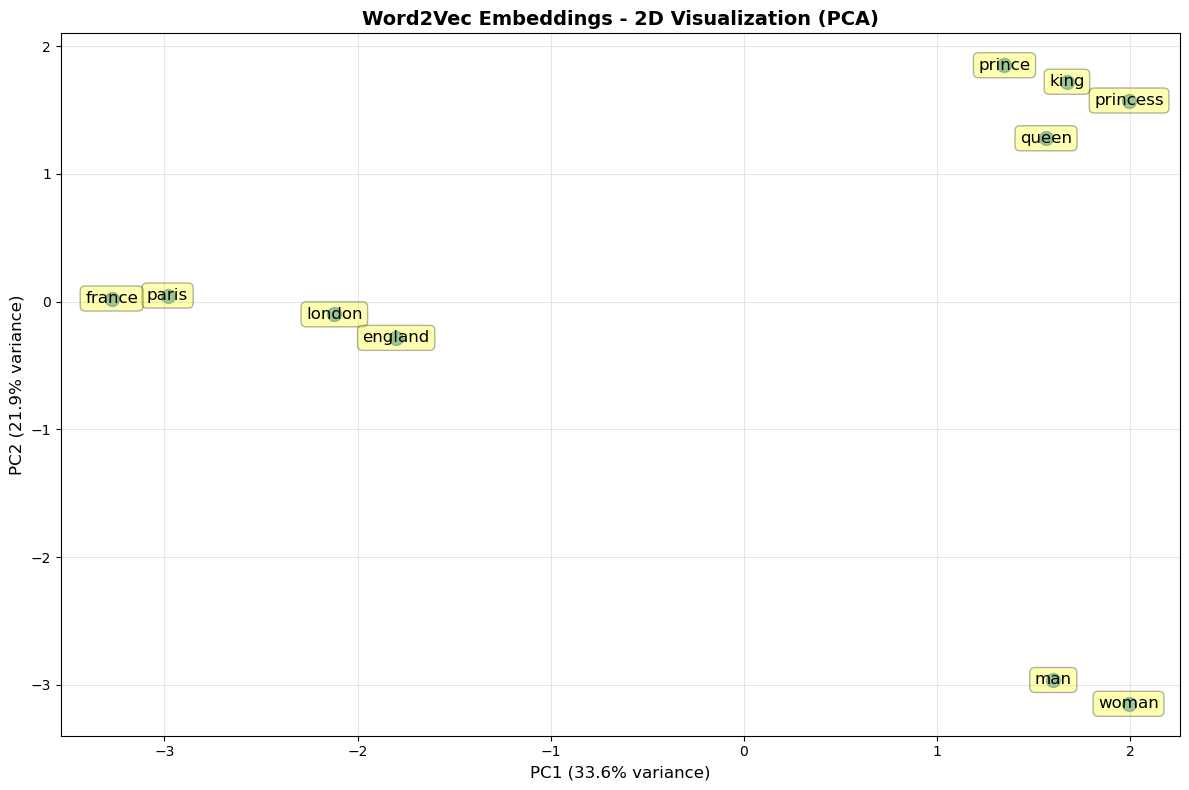

Visualized 10 words
Explained variance: 55.48%


In [22]:
# Select words to visualize
visualize_words = ['king', 'queen', 'man', 'woman', 'prince', 'princess', 
                  'paris', 'london', 'france', 'england']

# Extract vectors for selected words
vectors_to_plot = []
plot_labels = []

for word in visualize_words:
    if word in model:
        vectors_to_plot.append(model[word])
        plot_labels.append(word)

if len(vectors_to_plot) > 1:
    # Apply PCA to reduce to 2D
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(np.array(vectors_to_plot))
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.6, s=100)
    
    # Add labels to points
    for i, label in enumerate(plot_labels):
        plt.annotate(label, (vectors_2d[i, 0], vectors_2d[i, 1]), 
                    fontsize=12, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    plt.title('Word2Vec Embeddings - 2D Visualization (PCA)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Visualized {len(plot_labels)} words")
    print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2%}")
else:
    print("Not enough words available for visualization")

## Summary

**Key Concepts Demonstrated:**

1. **Word to Vector Conversion**: Each word is represented as a dense vector of numbers
2. **Semantic Meaning**: Words with similar meanings have similar vectors
3. **Vector Operations**: We can perform arithmetic on vectors to capture relationships
4. **Similarity Metrics**: Cosine similarity measures how related two words are
5. **Visualization**: PCA helps us visualize high-dimensional vectors in 2D

**Applications:**
- Natural Language Processing (NLP)
- Machine Learning pipelines
- Text classification and clustering
- Recommendation systems
- Semantic search

Word2Vec remains a fundamental technique in deep learning and is the foundation for more advanced models like Word2Vec used in modern transformer-based architectures.